# 🧭 Planificación de rutas con A* sobre mapas F1TENTH
Este notebook guía paso a paso el proceso de:
- Cargar un mapa (`.yaml` + `.png`)
- Binarizar la imagen
- Aplicar downsampling
- Convertir a una grilla de planificación (formato `Grid`)
- Calcular una ruta óptima con A*
- Exportar la ruta como CSV con coordenadas reales (`x, y` en metros)

## 📥 Entradas:
- `example_map.yaml` + `example_map.png`
- `downsample_factor`: entero
- `start`: coordenadas reales `(x, y)`
- `goal`: coordenadas reales `(x, y)`
- `planner`: nombre del algoritmo (por defecto `'a_star'`)

## 📤 Salidas:
- Visualización del mapa binarizado y reducido
- Ruta generada
- Archivo CSV con los waypoints reales

In [1]:
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import sys
import os

notebook_dir = os.getcwd()
project_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
sys.path.append(project_dir)

In [2]:
def load_and_binarize_map(yaml_path):
    with open(yaml_path, 'r') as f:
        config = yaml.safe_load(f)
    img_path = Path(yaml_path).parent / config['image']
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    resolution = config['resolution']
    origin = config['origin']
    binary = np.zeros_like(img, dtype=np.uint8)
    binary[img < int(0.45 * 255)] = 1
    return img, binary, resolution, origin

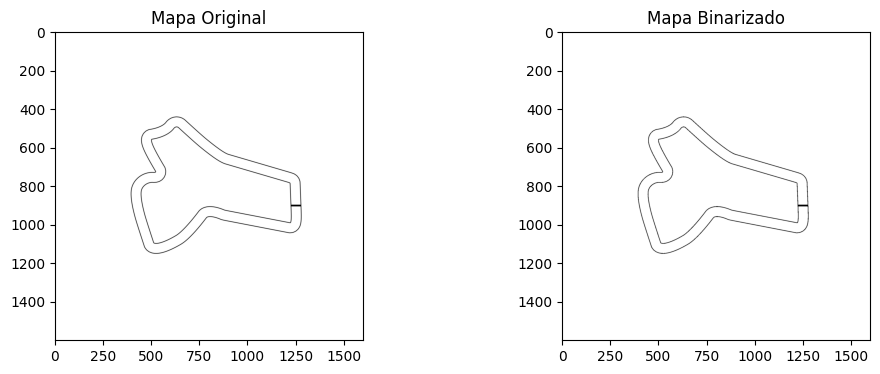

In [3]:
# Cambia esto según tu ruta real
yaml_path = 'example_map.yaml'
original_img, binary_img, resolution, origin = load_and_binarize_map(yaml_path)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.title('Mapa Original')
plt.imshow(original_img, cmap='gray')
plt.subplot(1,2,2)
plt.title('Mapa Binarizado')
plt.imshow(binary_img, cmap='gray_r')
plt.show()

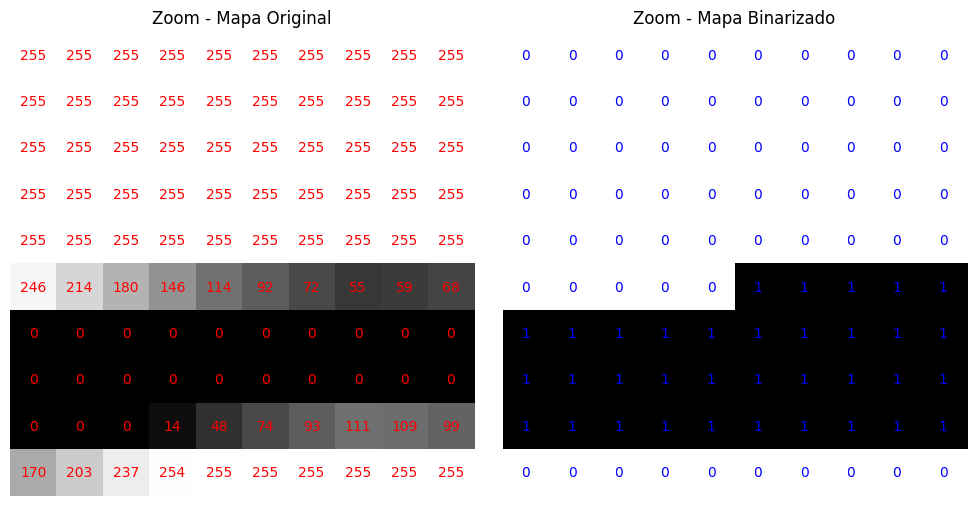

In [4]:
def get_bounding_box_around_obstacle(binary_img, zoom_size=50):
    # Buscar los píxeles donde hay obstáculos
    ys, xs = np.where(binary_img == 1)
    
    if len(xs) == 0 or len(ys) == 0:
        raise ValueError("No se encontraron obstáculos en el mapa binarizado.")

    # Tomamos el centro del primer obstáculo como punto de interés
    center_x = xs[0]
    center_y = ys[0]

    # Definir los bordes del recorte
    half_size = zoom_size // 2
    x_min = max(0, center_x - half_size)
    y_min = max(0, center_y - half_size)
    x_max = min(center_x + half_size, binary_img.shape[1])
    y_max = min(center_y + half_size, binary_img.shape[0])

    return x_min, x_max, y_min, y_max

# Definir tamaño del recorte
zoom_size = 10  # o 80 si quieres ver más

# Obtener zona de zoom centrada en un borde
x_min, x_max, y_min, y_max = get_bounding_box_around_obstacle(binary_img, zoom_size)

# Recortar
original_crop = original_img[y_min:y_max, x_min:x_max]
binary_crop = binary_img[y_min:y_max, x_min:x_max]

# Mostrar
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(original_crop, cmap='gray')
axs[0].set_title("Zoom - Mapa Original")
axs[0].axis('off')
for i in range(original_crop.shape[0]):
    for j in range(original_crop.shape[1]):
        axs[0].text(j, i, f'{original_crop[i, j]:.0f}', 
                    ha='center', va='center', color='red', fontsize=10)

axs[1].imshow(binary_crop, cmap='gray_r')
axs[1].set_title("Zoom - Mapa Binarizado")
axs[1].axis('off')
for i in range(binary_crop.shape[0]):
    for j in range(binary_crop.shape[1]):
        axs[1].text(j, i, str(binary_crop[i, j]), 
                    ha='center', va='center', color='blue', fontsize=10)

plt.tight_layout()
plt.show()


In [5]:
def downsample(binary_map, factor):
    dilated = cv2.dilate(binary_map, np.ones((5,5), np.uint8), iterations=2)
    down = cv2.resize(dilated.astype(np.float32),
                      (binary_map.shape[1] // factor, binary_map.shape[0] // factor),
                      interpolation=cv2.INTER_AREA)
    rebinarized = (down > 0.1).astype(np.uint8)
    return rebinarized

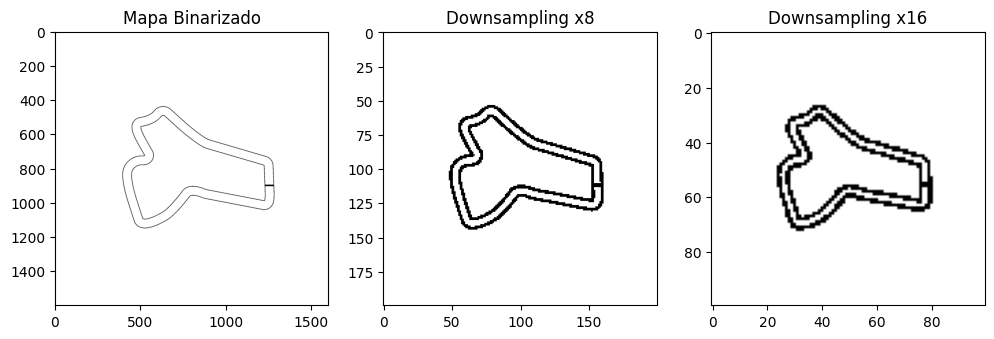

In [11]:
factor = 8
downsampled = downsample(binary_img, factor)
factor2 = 16
downsampled2 = downsample(binary_img, factor2)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title('Mapa Binarizado')
plt.imshow(binary_img, cmap='gray_r')
plt.subplot(1,3,2)
plt.title(f'Downsampling x{factor}')
plt.imshow(downsampled, cmap='gray_r')
plt.subplot(1,3,3)
plt.title(f'Downsampling x{factor2}')
plt.imshow(downsampled2, cmap='gray_r')
plt.show()

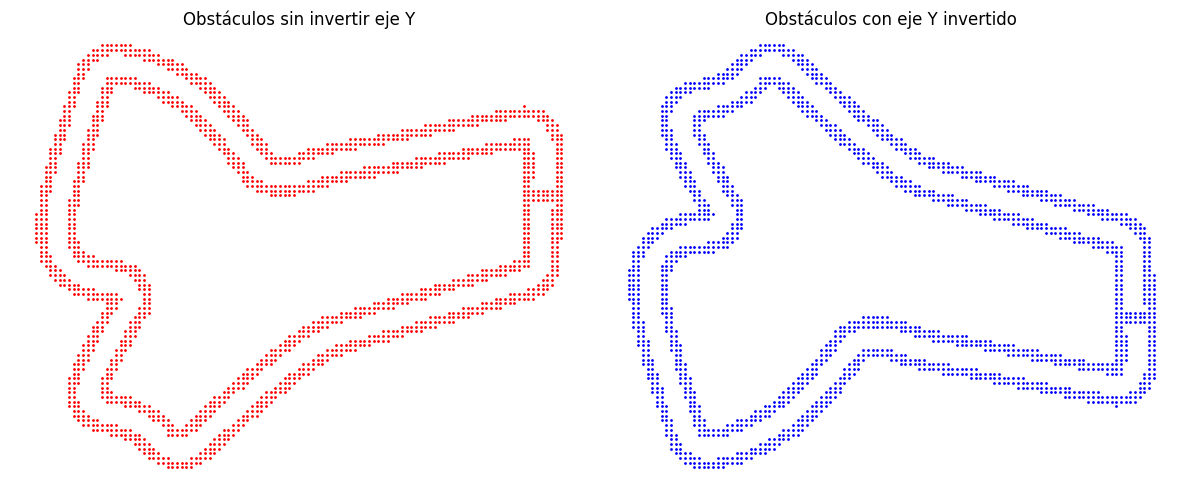

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de tener `downsampled` binarizado
# downsampled = load_map_inter_factor(...)[0]
h, w = downsampled.shape

# Obtener obstáculos de ambas formas
def get_obstacles_normal(map_bin):
    return set((x, y) for y in range(map_bin.shape[0]) for x in range(map_bin.shape[1]) if map_bin[y, x] == 1)

def get_obstacles_inverted(map_bin):
    h = map_bin.shape[0]
    return set((x, h - 1 - y) for y in range(map_bin.shape[0]) for x in range(map_bin.shape[1]) if map_bin[y, x] == 1)

obstacles_normal = get_obstacles_normal(downsampled)
obstacles_inverted = get_obstacles_inverted(downsampled)

# Separar en listas para graficar
x_normal, y_normal = zip(*obstacles_normal)
x_inverted, y_inverted = zip(*obstacles_inverted)

# Visualizar solo los puntos de obstáculos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Obstáculos sin invertir eje Y")
plt.scatter(x_normal, y_normal, s=1, c='red')
plt.axis('equal')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Obstáculos con eje Y invertido")
plt.scatter(x_inverted, y_inverted, s=1, c='blue')
# No invertimos el eje Y aquí: así lo vería el algoritmo
plt.axis('equal')
plt.axis('off')

plt.tight_layout()
plt.show()




In [13]:
def world_to_map(x, y, resolution, origin):
    mx = int((x - origin[0]) / resolution)
    my = int((y - origin[1]) / resolution)
    return (mx, my)

def map_to_world(mx, my, resolution, origin):
    x = mx * resolution + origin[0]
    y = my * resolution + origin[1]
    return (x, y)

## 🔧 Planificador A*
En este notebook no se ejecuta A* directamente, pero puedes usar tu clase `SearchFactory()` de `python_motion_planning` para:
```python
start = world_to_map(x_start, y_start, resolution, origin)
goal = world_to_map(x_goal, y_goal, resolution, origin)
planner = SearchFactory()('a_star', start=start, goal=goal, env=grid)
cost, path, _ = planner.plan()
```
Y luego visualizar o exportar la ruta.

In [14]:
def save_path_as_csv(path, filename, resolution, origin, image_height):
    with open(filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['x', 'y'])
        for x_map, y_map in reversed(path):
            x, y = map_to_world(x_map, y_map, resolution, origin)
            writer.writerow([x, y])

Costo: 5.0, Nodos en el camino: 6
✔️ Ruta guardada como astar_path_real.csv


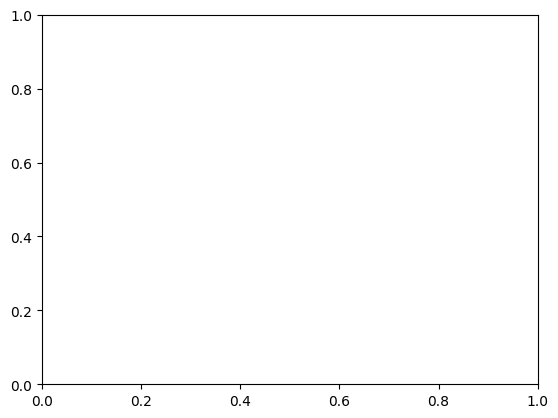

In [15]:
# ✅ Ejecutar el planificador A*
from python_motion_planning.utils import Grid, SearchFactory

# Convertir binario reducido a entorno Grid
obstacles = get_obstacles_normal(downsampled)
h, w = downsampled.shape
grid = Grid(w, h)
grid.update(obstacles)

# Definir puntos de inicio y fin en metros (ajusta según tu mapa)
x_start, y_start = 0.0, 1.0
x_goal, y_goal = 0.0, -1.5

# Convertir a coordenadas de mapa
start = world_to_map(x_start, y_start, resolution * factor, origin)
goal = world_to_map(x_goal, y_goal, resolution * factor, origin)

# Ejecutar planificador
planner = SearchFactory()('a_star', start=start, goal=goal, env=grid)
cost, path, _ = planner.plan()
print(f'Costo: {cost}, Nodos en el camino: {len(path)}')

# Guardar el resultado como CSV
save_path_as_csv(path, 'astar_path_real.csv', resolution * factor, origin, downsampled.shape[0])
print('✔️ Ruta guardada como astar_path_real.csv')

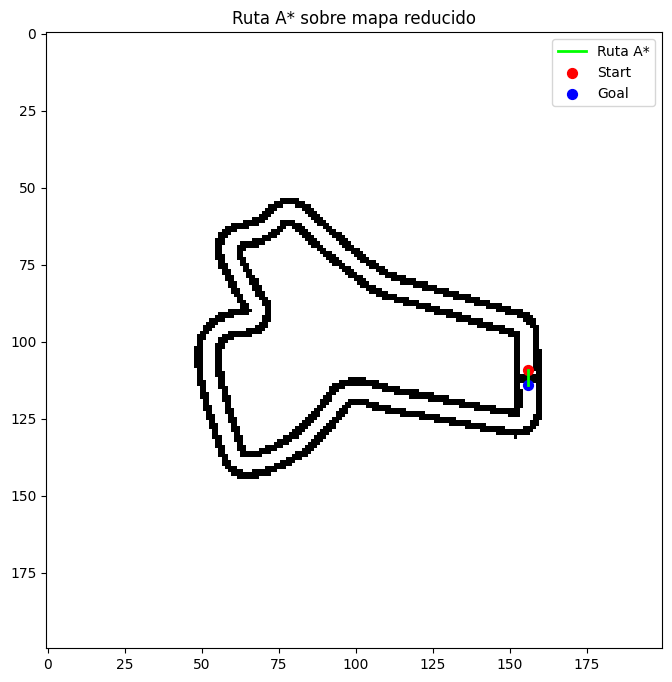

In [16]:
# Visualizar la ruta planificada sobre el mapa reducido
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(downsampled, cmap='gray_r', origin='upper')

# Mostrar ruta (invertir eje Y)
path_x = [pt[0] for pt in path]
path_y = [h - 1 - pt[1] for pt in path]  # invertir eje Y
plt.plot(path_x, path_y, color='lime', linewidth=2, label='Ruta A*')

# Mostrar puntos de inicio y fin
plt.scatter(start[0], h - 1 - start[1], color='red', s=50, label='Start')
plt.scatter(goal[0], h - 1 - goal[1], color='blue', s=50, label='Goal')

plt.title("Ruta A* sobre mapa reducido")
plt.legend()
plt.show()
